# Первичный анализ и трансформация исходного датасета в версии Raw и Easy

## Исходный файл

In [41]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "data" / "data-15-structure-3.csv"

if DATASET_PATH.exists():
    df_orig = pd.read_csv(DATASET_PATH)
    print("Датасет успешно загружен.")
    print(f"Строк: {len(df_orig)}")
else:
    print(f"Файл не найден по пути: {DATASET_PATH}")  

Датасет успешно загружен.
Строк: 23086


##### Дополнительные функции

In [39]:
def calculate_missing_stats(df, columns):
    """
    Вычисляет процент пропусков для списка колонок и общий средний процент.
    """
    total_rows = len(df)
    null_percentages = (df[columns].isnull().sum() / total_rows) * 100

    total_nulls = df[columns].isnull().sum().sum()
    total_cells = total_rows * len(columns)
    avg_empty_percent = (total_nulls / total_cells) * 100

    return null_percentages, avg_empty_percent


### Анализ

#### Общая информация

In [42]:
print(f"Размер датасета: {df_orig.shape}")

print("\nПервые 5 строк")
df_orig.head(5)

Размер датасета: (23086, 24)

Первые 5 строк


,Идентификатор записи реестра,Регистрационный номер,Дата регистрации,Название культурной ценности,Полноценное визуальное описание,Код,Классификация культурной ценности,Комментарий,Код [2],Категория культурной ценности,...,Комментарий [4],Высота,Ширина,Длина,Вес,Идентификатор записи реестра [2],Описание состояния сохранности,"Идентифицирующие признаки предмета (надписи, подписи, клейма, пометы, экслибрисы и т.п.)",дата создания объекта,дата обновления объекта
0,12669127,23565,2025-12-24,"Каменев И.Ю. ""Фазы луны"" (триптих, центральная...",NaN,16.0,ЖИВОПИСЬ,NaN,NaN,NaN,...,NaN,180 см,120 см,NaN,NaN,[],NaN,NaN,2025-12-24T15:53:29+03:00,2025-12-24T15:53:29+03:00
1,12669129,23566,2025-12-24,"Каменев И.Ю. ""Фазы луны"" (триптих, левая часть...",NaN,16.0,ЖИВОПИСЬ,NaN,NaN,NaN,...,NaN,180 см,60 см,NaN,NaN,[],NaN,NaN,2025-12-24T15:53:29+03:00,2025-12-24T15:53:29+03:00
2,12669131,23567,2025-12-24,"Каменев И.Ю. ""Фазы луны"" (триптих, правая част...",NaN,16.0,ЖИВОПИСЬ,NaN,NaN,NaN,...,NaN,180 см,60 см,NaN,NaN,[],NaN,NaN,2025-12-24T15:53:29+03:00,2025-12-24T15:53:29+03:00
3,12669133,23568,2025-12-24,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,16.0,ЖИВОПИСЬ,NaN,NaN,NaN,...,NaN,150 см,100 см,NaN,NaN,[],NaN,NaN,2025-12-24T15:53:29+03:00,2025-12-24T15:53:29+03:00
4,12669135,23569,2025-12-24,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,16.0,ЖИВОПИСЬ,NaN,NaN,NaN,...,NaN,80 см,60 см,NaN,NaN,[],NaN,NaN,2025-12-24T15:53:29+03:00,2025-12-24T15:53:29+03:00


In [43]:
print("Техническая информация:")
df_orig.info()

Техническая информация:
<class 'pandas.DataFrame'>
RangeIndex: 23086 entries, 0 to 23085
Data columns (total 24 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Идентификатор записи реестра                                                              23086 non-null  int64  
 1   Регистрационный номер                                                                     23086 non-null  int64  
 2   Дата регистрации                                                                          23086 non-null  str    
 3   Название культурной ценности                                                              21997 non-null  str    
 4   Полноценное визуальное описание                                                           0 non-null      float64
 5   Код                                     

In [44]:
print("Распределение всех категорий в исходных данных:")
category_counts = df_orig['Классификация культурной ценности'].value_counts()
print(category_counts)

Распределение всех категорий в исходных данных:
Классификация культурной ценности
ИКОНА                                                 2718
ЖИВОПИСЬ                                              2592
РАЗНОЕ                                                1213
ПРЕДМЕТЫ НУМИЗМАТИКИ И БОНИСТИКИ                       682
ОБРАЗЦЫ ФЛОРЫ И ФАУНЫ                                  557
ОТТИСК                                                 477
АРХИВНЫЕ ДОКУМЕНТЫ                                     345
МОНЕТА / МЕДАЛЬ                                        239
РИСУНОК                                                179
ПРЕДМЕТЫ ФАЛЕРИСТИКИ И СФРАГИСТИКИ                     141
ПЕЧАТНЫЕ ИЗДАНИЯ                                        91
КЕРАМИКА                                                73
ОРУЖИЕ ХОЛОДНОЕ                                         68
ОРУЖИЕ ОГНЕСТРЕЛЬНОЕ                                    51
ВЫШИВКА                                                 48
ЭМАЛЬ                            

In [45]:
categories = ['ЖИВОПИСЬ', 'АРХИВНЫЕ ДОКУМЕНТЫ', 'МОНЕТА / МЕДАЛЬ']

print("--- ПРИМЕРЫ ДАННЫХ ИЗ РЕЕСТРА ---\n")

df_orig.columns = df_orig.columns.str.strip()

for cat in categories:
    print(f"=== КАТЕГОРИЯ: {cat} ===")
    
    # Берем 2 случайных примера, где название не пустое
    sample = df_orig[df_orig['Классификация культурной ценности'] == cat].dropna(subset=['Название культурной ценности']).sample(2)
    
    for i, row in sample.iterrows():
        print(f"ОБЪЕКТ: {row['Название культурной ценности']}")
        print(f"СОСТОЯНИЕ: {row['Описание состояния сохранности']}")
        print(f"ПРИЗНАКИ: {row['Идентифицирующие признаки предмета (надписи, подписи, клейма, пометы, экслибрисы и т.п.)']}")
        print(f"РАЗМЕРЫ: {row['Высота']} x {row['Ширина']}")
        print("-" * 30)
    print("\n")

--- ПРИМЕРЫ ДАННЫХ ИЗ РЕЕСТРА ---

=== КАТЕГОРИЯ: ЖИВОПИСЬ ===
ОБЪЕКТ: Село Карагл Тамбовской губернии — родина Г.В. Чичерина (Этюд)    Автор: Анисимов Юлиан Павлович
СОСТОЯНИЕ: nan
ПРИЗНАКИ: Размеры: B. 36, Ш. 46,5    Инвентарный номер: Инв. №67. Инв. № 751 и №1093 по ИК ВКМ
РАЗМЕРЫ: nan x 46,5
------------------------------
ОБЪЕКТ: Лес зимой (название придуманное); Снежное поле и лес на пригорке (название последнее)    Автор: Жуковская Александра Александровна, Игнатьева (урож., художник)    Школа / Место издания: Россия, Украина    Период оригинала: 1 половина 20 век
СОСТОЯНИЕ: nan
ПРИЗНАКИ: Стиль: Серый, Белый: поле снежное    Размеры: В. 23.5, Ш. 34 (без обрамления ?)
РАЗМЕРЫ: 23.5 x 34
------------------------------


=== КАТЕГОРИЯ: АРХИВНЫЕ ДОКУМЕНТЫ ===
ОБЪЕКТ: МОКМ КП-2921/3 Грамота почетная Шляхтеру Льву Моисеевичу, токарю промкомбината Дальстроя, за высокие показатели в работе Бумага, размер не зафиксирован. Поступление 1973 г.
СОСТОЯНИЕ: Не зафиксировано
ПРИЗНАКИ: Не зафикс

#### Проверка на пропуски

In [46]:
cols = ['Высота', 'Ширина', 'Длина', 'Вес']
per_col, total_avg = calculate_missing_stats(df_orig, cols)
print("Процент пропусков по каждой колонке:")
print(per_col.map('{:.2f}%'.format))
print(f"Средняя 'пустота' ключевых признаков: {total_avg:.2f}%")

Процент пропусков по каждой колонке:
Высота    53.15%
Ширина    53.16%
Длина     89.20%
Вес       99.98%
dtype: str
Средняя 'пустота' ключевых признаков: 73.87%


In [47]:
# Проверка описательных полей на наличие пропусков.

# Список столбцов с описательными характеристиками для анализа.
desc_columns = [
    'Название культурной ценности', 
    'Полноценное визуальное описание', 
    'Описание состояния сохранности', 
    'Идентифицирующие признаки предмета (надписи, подписи, клейма, пометы, экслибрисы и т.п.)'
]

# Формирование сводной таблицы с анализом пропущенных значений.
desc_stats = pd.DataFrame({
    'Заполнено (Non-Null)': df_orig[desc_columns].notnull().sum(),
    'Пусто (Null)': df_orig[desc_columns].isnull().sum(),
    'Процент пустоты': (df_orig[desc_columns].isnull().sum() / len(df_orig) * 100).map('{:.2f}%'.format)
})

print("Сравнение заполненности колонок с описаниями:")
display(desc_stats)

# Дополнительная проверка: а есть ли строки, где ВООБЩЕ НЕТ никакого описания?
# Проверяем строки, где все выбранные колонки пустые
total_empty_rows = df_orig[desc_columns].isnull().all(axis=1).sum()

print(f"\nОбъектов без единого слова описания (во всех {len(desc_columns)} колонках): {total_empty_rows}")
print(f"Это {total_empty_rows / len(df_orig) * 100:.2f}% от всей базы.")

Сравнение заполненности колонок с описаниями:


,Заполнено (Non-Null),Пусто (Null),Процент пустоты
Название культурной ценности,21997,1089,4.72%
Полноценное визуальное описание,0,23086,100.00%
Описание состояния сохранности,4109,18977,82.20%
"Идентифицирующие признаки предмета (надписи, подписи, клейма, пометы, экслибрисы и т.п.)",20499,2587,11.21%



Объектов без единого слова описания (во всех 4 колонках): 606
Это 2.62% от всей базы.


## Raw версия

In [48]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "data" / "culture_large_dataset_raw.csv"

if DATASET_PATH.exists():
    df_raw = pd.read_csv(DATASET_PATH)
    print("Датасет успешно загружен.")
    print(f"Строк: {len(df_raw)}")
else:
    print(f"Файл не найден по пути: {DATASET_PATH}")  

Датасет успешно загружен.
Строк: 7550


### Анализ

In [49]:
print(f"Размер датасета: {df_raw.shape}")

print("\nПервые 5 строк")
df_raw.head(5)

Размер датасета: (7550, 14)

Первые 5 строк


,title,marks,condition,category,height,width,length,weight,create_date,target_group,is_painting_hint,is_icon_hint,is_coin_hint,is_doc_hint
0,"Каменев И.Ю. ""Фазы луны"" (триптих, центральная...",NaN,NaN,ЖИВОПИСЬ,180 см,120 см,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
1,"Каменев И.Ю. ""Фазы луны"" (триптих, левая часть...",NaN,NaN,ЖИВОПИСЬ,180 см,60 см,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
2,"Каменев И.Ю. ""Фазы луны"" (триптих, правая част...",NaN,NaN,ЖИВОПИСЬ,180 см,60 см,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
3,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,NaN,ЖИВОПИСЬ,150 см,100 см,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,1,0,0
4,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,NaN,ЖИВОПИСЬ,80 см,60 см,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,1,0,0


In [50]:
cols = ['height', 'width', 'length', 'weight']
per_col, total_avg = calculate_missing_stats(df_raw, cols)
print("Процент пропусков по каждой колонке:")
print(per_col.map('{:.2f}%'.format))
print(f"Средняя 'пустота' ключевых признаков: {total_avg:.2f}%")

Процент пропусков по каждой колонке:
height     36.68%
width      31.58%
length     97.44%
weight    100.00%
dtype: str
Средняя 'пустота' ключевых признаков: 66.42%


In [51]:
# Группируем данные по целевой группе и считаем сумму хинтов в каждой

hint_columns = ['is_painting_hint', 'is_icon_hint', 'is_coin_hint', 'is_doc_hint']

coverage_matrix = df_raw.groupby('target_group')[hint_columns].sum()

print("Матрица покрытия (хинты vs реальные группы):")
display(coverage_matrix)

Матрица покрытия (хинты vs реальные группы):


,is_painting_hint,is_icon_hint,is_coin_hint,is_doc_hint
target_group,,,,
ART,1700,441,70,296
DOCUMENTS,28,46,45,338
ICON,62,2656,336,55
NUMISMATICS,18,9,1050,127


### Приведение к одинаковым единицам измерения

#### Приведение

In [52]:
import numpy as np
import re

# Словари от ИИ-агента
TO_CM = {
    'см': 1.0, 'см.': 1.0, 'cm': 1.0, 'cм': 1.0, 'cм.': 1.0,
    'мм': 0.1, 'мм.': 0.1, 'mm': 0.1,
    'м': 100.0, 'м.': 100.0, 'm': 100.0,
    'дм': 10.0, 'дм.': 10.0, 'dm': 10.0,
    'дюйм': 2.54,  # английский; если французский — 2.707
    'вершок': 4.445, 'верш': 4.445,
    'аршин': 71.12, 'арш': 71.12,
    'фут': 30.48, 'ft': 30.48,
}
TO_GRAM = {
    'г': 1.0, 'г.': 1.0, 'гр': 1.0, 'гр.': 1.0, 'g': 1.0, 'gr': 1.0,
    'кг': 1000.0, 'кг.': 1000.0, 'kg': 1000.0,
    'мг': 0.001, 'мг.': 0.001, 'mg': 0.001,  # миллиграммы!
}

In [53]:
def smart_convert(value, is_weight=False):
    """
    Универсальный конвертер строки в число с нормализацией единиц измерения.

    Функция извлекает первое числовое значение из строки и приводит его к базовой 
    единице измерения (сантиметры для размеров, граммы для веса), используя 
    словари коэффициентов (TO_CM или TO_GRAM).

    Args:
        value (any): Входное значение (строка, число или NaN).
        is_weight (bool): Флаг, указывающий, обрабатывается ли вес (True) 
            или линейный размер (False). По умолчанию False.

    Returns:
        float: Числовое значение в базовых единицах или np.nan, если извлечение невозможно.
    """
    # Превращаем в строку и очищаем от пробелов
    s = str(value).lower().strip()

    # Если ячейка пустая (была NaN или стала ""), возвращаем честный NaN
    if s in ['nan', 'none', '']:
        return np.nan
    
    # Извлекаем первое число из строки
    match = re.search(r"(\d+\.?\d*)", s)
    if not match:
        return np.nan
    
    try:
        num = float(match.group(1).replace(',', '.'))

        # Ищем единицу измерения
        multiplier = None
        if is_weight:
            lookup = TO_GRAM
        else:
            lookup = TO_CM
        
        # Ищем любую единицу из словаря в строке
        for unit, val in lookup.items():
            if unit in s:
                multiplier = val
                break
        
        # Если единиц нет (просто число) — берем значение по умолчанию
        if multiplier is None:
            return num # По умолчанию см или г
        
        return num * multiplier
    
    except:
        return np.nan

In [54]:
def extract_weight_from_text(row):
    """
    Извлекает значение веса из текстовых полей title и marks.

    Если в строке уже заполнено поле 'weight', функция возвращает его без изменений.
    В противном случае ищет в тексте паттерны вида "вес 500 гр" или "вес: 1.2 кг",
    конвертирует найденное значение в граммы и возвращает его.

    Args:
        row (pd.Series или dict): Строка датафрейма, содержащая поля 'weight', 
            'title' и 'marks'.

    Returns:
        float: Вес в граммах или np.nan, если вес не найден или не распознан.
    """
    if pd.notna(row['weight']): 
        return row['weight']
    
    text = f"{row['title']} {row['marks']}".lower()
    # Ищем паттерн: "вес 720 гр" или "вес: 8,5 кг"
    match = re.search(r"вес\s*:?\s*(\d+[.,]?\d*)\s*(гр|г|кг|kg|g)", text)
    if match:
        val = float(match.group(1).replace(',', '.'))
        unit = match.group(2)
        return val * TO_GRAM.get(unit, 1.0)
    
    return np.nan

In [55]:
# Сначала чистим то, что уже в колонках
for col in ['height', 'width', 'length']:
    df_raw[col] = df_raw[col].apply(smart_convert, is_weight=False)

df_raw['weight'] = df_raw['weight'].apply(smart_convert, is_weight=True)

# 2. Дозаполняем ВЕС из текстовых описаний
df_raw['weight'] = df_raw.apply(extract_weight_from_text, axis=1)

# Проверка результата
print("Умная конвертация завершена!")
print("Статистика очистки:")
for col in ['height', 'width', 'length', 'weight']:
    success_count = df_raw[col].notna().sum()
    print(f"Колонка {col}: успешно преобразовано {success_count} числовых значений")

Умная конвертация завершена!
Статистика очистки:
Колонка height: успешно преобразовано 4781 числовых значений
Колонка width: успешно преобразовано 5166 числовых значений
Колонка length: успешно преобразовано 193 числовых значений
Колонка weight: успешно преобразовано 86 числовых значений


#### Анализ

In [56]:
df_raw.head()

,title,marks,condition,category,height,width,length,weight,create_date,target_group,is_painting_hint,is_icon_hint,is_coin_hint,is_doc_hint
0,"Каменев И.Ю. ""Фазы луны"" (триптих, центральная...",NaN,NaN,ЖИВОПИСЬ,180.0,120.0,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
1,"Каменев И.Ю. ""Фазы луны"" (триптих, левая часть...",NaN,NaN,ЖИВОПИСЬ,180.0,60.0,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
2,"Каменев И.Ю. ""Фазы луны"" (триптих, правая част...",NaN,NaN,ЖИВОПИСЬ,180.0,60.0,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,0,0,0
3,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,NaN,ЖИВОПИСЬ,150.0,100.0,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,1,0,0
4,"Каменев И.Ю. ""Спаситель, попирающий космически...",NaN,NaN,ЖИВОПИСЬ,80.0,60.0,NaN,NaN,2025-12-24T15:53:29+03:00,ART,1,1,0,0


In [57]:
# Загружаем исходный сырой файл для сравнения
df_old = pd.read_csv(DATASET_PATH)
cols = ['height', 'width', 'length', 'weight']

# Считаем количество НЕ пустых значений
before = df_old[cols].notna().sum()
after = df_raw[cols].notna().sum()
recovered = after - before

# Выводим красивую таблицу сравнения
comparison = pd.DataFrame({
    'Было (Raw)': before,
    'Стало (Cleaned)': after,
    'Восстановлено': recovered,
    'Прирост %': (recovered / before * 100).fillna(0).map('{:.1f}%'.format)
})

print("СТАТИСТИКА ВОССТАНОВЛЕНИЯ ДАННЫХ:")
display(comparison)
print(f"\nВсего удалось восстановить {recovered.sum()} числовых значений из текстовых описаний!")

СТАТИСТИКА ВОССТАНОВЛЕНИЯ ДАННЫХ:


,Было (Raw),Стало (Cleaned),Восстановлено,Прирост %
height,4781,4781,0,0.0%
width,5166,5166,0,0.0%
length,193,193,0,0.0%
weight,0,86,86,inf%



Всего удалось восстановить 86 числовых значений из текстовых описаний!


In [58]:
cols = ['height', 'width', 'length', 'weight']
per_col, total_avg = calculate_missing_stats(df_raw, cols)

print("Процент пропусков по каждой колонке:")
print(per_col.map('{:.2f}%'.format))
print(f"Средняя 'пустота' ключевых признаков: {total_avg:.2f}%")

Процент пропусков по каждой колонке:
height    36.68%
width     31.58%
length    97.44%
weight    98.86%
dtype: str
Средняя 'пустота' ключевых признаков: 66.14%


### Заполнение пустых ячеек

#### Приведение

In [59]:
# Коэффициенты пересчета в САНТИМЕТРЫ и ГРАММЫ
UNIT_TO_CM = {'мм': 0.1, 'mm': 0.1, 'м': 100.0, 'm': 100.0, 'см': 1.0, 'cm': 1.0}
UNIT_TO_G = {'кг': 1000.0, 'kg': 1000.0, 'мг': 0.001, 'mg': 0.001, 'г': 1.0, 'гр': 1.0, 'грамм': 1.0}

# Регулярки от агента (добавлены переменные для удобства)
RE_3D = re.compile(r'(?<![\dxх*×])(\d{1,4}(?:[.,]\d+)?)\s*[xх*×]\s*(\d{1,4}(?:[.,]\d+)?)\s*[xх*×]\s*(\d{1,4}(?:[.,]\d+)?)\s*(см\.?|мм\.?|м\.?|cm\.?|mm\.?)?', re.I)
RE_2D = re.compile(r'(?<![\dxх*×])(\d{1,4}(?:[.,]\d+)?)\s*[xх*×]\s*(\d{1,4}(?:[.,]\d+)?)\s*(см\.?|мм\.?|м\.?|cm\.?|mm\.?)', re.I)
RE_DIAM = re.compile(r'(?:\bдиаметр[а-я]*|\bдиам\.?|\bd\d?)\s*[:\-–—=]?\s*(\d+(?:[.,]\d+)?)\s*(см\.?|мм\.?|м\.?|cm\.?|mm\.?)?', re.I)
RE_WEIGHT = re.compile(r'\bвес\b\s*[:\-–—=]?\s*(\d+(?:[.,]\d+)?)\s*(г\.?|гр\.?|кг\.?|грамм[а-я]*|килограмм[а-я]*)', re.I)

In [60]:
def to_float(value, unit, mapping, default=1.0):
    """
    Преобразует строковое значение в число с учетом коэффициента единицы измерения.

    Функция выполняет базовую очистку строки (замена запятых на точки), 
    преобразование в float и поиск множителя в словаре маппинга на основе 
    указанной единицы измерения.

    Args:
        value (str/float): Числовое значение (например, '17,5').
        unit (str): Строка с единицей измерения (например, 'мм' или 'kg').
        mapping (dict): Словарь коэффициентов пересчета (например, UNIT_TO_CM).
        default (float): Коэффициент по умолчанию, если единица измерения 
            не указана (None). По умолчанию 1.0 (для сантиметров).

    Returns:
        float: Итоговое числовое значение (число * коэффициент) или np.nan при ошибке.
    """
    if not value: 
        return np.nan
    
    num = float(str(value).replace(',', '.'))

    # Ищем коэффициент в словаре (например, 'мм' -> 0.1)
    # Если единица не указана (None), берем default (для размеров это 1.0, т.е. см)
    coef = default
    if unit:
        unit_clean = str(unit).lower().replace('.', '').strip()
        
        for k, v in mapping.items():
            if k in unit_clean:
                coef = v
                break
    
    return num * coef

In [61]:
def parse_text_dimensions(row):
    """
    Комплексный парсер физических характеристик из текстового описания.

    Функция анализирует объединенный текст полей 'title' и 'marks' и пытается 
    заполнить пустые (NaN) значения размеров и веса, используя регулярные выражения.
    Поиск идет в следующем приоритете:
    1. 3D размеры (Высота x Ширина x Длина).
    2. 2D размеры (Высота x Ширина).
    3. Диаметр (дублируется в Высоту и Ширину).
    4. Вес.

    Args:
        row (pd.Series): Строка датафрейма с полями 'height', 'width', 
            'length', 'weight', 'title' и 'marks'.

    Returns:
        pd.Series: Измененная строка с заполненными физическими характеристиками.
    """
    # Склеиваем текст для поиска
    text = f"{row['title']} {row['marks']}".lower()
    
    # Пробуем найти 3D (H x W x L)
    if pd.isna(row['height']) or pd.isna(row['length']):
        m = RE_3D.search(text)
        if m:
            row['height'] = to_float(m.group(1), m.group(4), UNIT_TO_CM)
            row['width']  = to_float(m.group(2), m.group(4), UNIT_TO_CM)
            row['length'] = to_float(m.group(3), m.group(4), UNIT_TO_CM)
            return row # Если нашли 3D, дальше можно не искать

    # Пробуем найти 2D (H x W)
    if pd.isna(row['height']) or pd.isna(row['width']):
        m = RE_2D.search(text)
        if m:
            row['height'] = to_float(m.group(1), m.group(3), UNIT_TO_CM)
            row['width']  = to_float(m.group(2), m.group(3), UNIT_TO_CM)

    # Пробуем найти Диаметр (пишем и в H, и в W)
    if pd.isna(row['height']):
        m = RE_DIAM.search(text)
        if m:
            val = to_float(m.group(1), m.group(2), UNIT_TO_CM)
            row['height'], row['width'] = val, val

    # Пробуем найти Вес
    if pd.isna(row['weight']):
        m = RE_WEIGHT.search(text)
        if m:
            row['weight'] = to_float(m.group(1), m.group(2), UNIT_TO_G)

    return row

#### Анализ

In [62]:
# Запускаем поиск по тексту
df_raw = df_raw.apply(parse_text_dimensions, axis=1)

# Проверяем результат
cols = ['height', 'width', 'length', 'weight']
per_col, total_avg = calculate_missing_stats(df_raw, cols)
print("Процент пропусков по каждой колонке:")
print(per_col.map('{:.2f}%'.format))
print(f"Средняя 'пустота' ключевых признаков: {total_avg:.2f}%")

Процент пропусков по каждой колонке:
height    26.05%
width     20.93%
length    97.32%
weight    98.70%
dtype: str
Средняя 'пустота' ключевых признаков: 60.75%


#### Приведение

In [63]:
# Заполняем пустоты ГЛОБАЛЬНОЙ МЕДИАНОЙ
for col in ['height', 'width', 'length', 'weight']:
    df_raw[col] = df_raw[col].fillna(df_raw[col].median())

# Заполняем остатки нулями, чтобы не было ошибок в ML
df_raw = df_raw.fillna(0)

#### Анализ

In [64]:
cols = ['height', 'width', 'length', 'weight']
per_col, total_avg = calculate_missing_stats(df_raw, cols)
print("Процент пропусков по каждой колонке:")
print(per_col.map('{:.2f}%'.format))
print(f"Средняя 'пустота' ключевых признаков: {total_avg:.2f}%")

Процент пропусков по каждой колонке:
height    0.00%
width     0.00%
length    0.00%
weight    0.00%
dtype: str
Средняя 'пустота' ключевых признаков: 0.00%


### Сохранеие easy версии

In [65]:
BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "data" / "culture_large_dataset_easy.csv"

# Кодируем целевую переменную (Target) в числа
# ART: 0, DOCUMENTS: 1, ICON: 2, NUMISMATICS: 3
df_raw['target_label'] = df_raw['target_group'].astype('category').cat.codes

# Удаляем всё лишнее (текст, старые категории), оставляем только числа
cols_to_keep = [
    'height', 'width', 'length', 'weight', 
    'is_painting_hint', 'is_icon_hint', 'is_coin_hint', 'is_doc_hint', 
    'target_label'
]
df_easy = df_raw[cols_to_keep]

# Сохраняем результат
df_easy.to_csv(DATASET_PATH, index=False, encoding='utf-8', sep=',', decimal='.', na_rep='NA')

## Easy версия

In [66]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "data" / "culture_large_dataset_easy.csv"

if DATASET_PATH.exists():
    df_easy = pd.read_csv(DATASET_PATH)
    print("Датасет успешно загружен.")
    print(f"Строк: {len(df_easy)}")
else:
    print(f"Файл не найден по пути: {DATASET_PATH}")  

Датасет успешно загружен.
Строк: 7550


### Анализ

In [67]:
print(f"Размер датасета: {df_easy.shape}")

print("\nПервые 10 строк")
df_easy.head(10)

Размер датасета: (7550, 9)

Первые 10 строк


,height,width,length,weight,is_painting_hint,is_icon_hint,is_coin_hint,is_doc_hint,target_label
0,180.0,120.0,28.75,834.75,1,0,0,0,0
1,180.0,60.0,28.75,834.75,1,0,0,0,0
2,180.0,60.0,28.75,834.75,1,0,0,0,0
3,150.0,100.0,28.75,834.75,1,1,0,0,0
4,80.0,60.0,28.75,834.75,1,1,0,0,0
5,80.0,60.0,28.75,834.75,1,1,0,0,0
6,48.0,79.0,28.75,834.75,1,0,0,0,0
7,40.0,43.0,28.75,834.75,0,0,0,0,1
8,40.0,43.0,28.75,834.75,0,0,1,0,3
9,16.3,9.2,16.00,834.75,1,0,0,1,1


In [68]:
print("Техническая информация:")
df_easy.info()

Техническая информация:
<class 'pandas.DataFrame'>
RangeIndex: 7550 entries, 0 to 7549
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            7550 non-null   float64
 1   width             7550 non-null   float64
 2   length            7550 non-null   float64
 3   weight            7550 non-null   float64
 4   is_painting_hint  7550 non-null   int64  
 5   is_icon_hint      7550 non-null   int64  
 6   is_coin_hint      7550 non-null   int64  
 7   is_doc_hint       7550 non-null   int64  
 8   target_label      7550 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 531.0 KB


### Обучение ML модели

In [69]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "data" / "culture_large_dataset_easy.csv"

if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
    print("Датасет успешно загружен.")
    print(f"Строк: {len(df)}")
else:
    print(f"Файл не найден по пути: {DATASET_PATH}") 

Датасет успешно загружен.
Строк: 7550


#### Обучение ML модели DecisionTreeClassifier

In [70]:
# Подготовка данных
# Выделяем признаки (X) и целевую переменную (y)
X = df.drop(['target_label'], axis=1)
y = df['target_label']

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Построение и обучение модели
# Ограничим глубину (max_depth), чтобы дерево не стало слишком запутанным
model = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Оценка результатов
predictions = model.predict(X_test)

print("\n--- Отчет о качестве (Decision Tree) ---")
print(classification_report(y_test, predictions))

# Маппинг для красивого вывода (чтобы видеть названия, а не цифры 0, 1, 2, 3)
target_names = {0: 'ART', 1: 'DOCUMENTS', 2: 'ICON', 3: 'NUMISMATICS'}

# Демонстрация предсказания
cnt = 10
print(f"\n--- Примеры прогнозов (первые {cnt}) ---")
for i in range(cnt):
    real_name = target_names.get(y_test.values[i])
    pred_name = target_names.get(predictions[i])
    print(f"Реально: {real_name:12} | Предсказано: {pred_name:12}")


--- Отчет о качестве (Decision Tree) ---
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       657
           1       0.65      0.94      0.77       111
           2       0.94      0.95      0.94       549
           3       0.95      0.98      0.97       193

    accuracy                           0.92      1510
   macro avg       0.88      0.94      0.90      1510
weighted avg       0.93      0.92      0.92      1510


--- Примеры прогнозов (первые 10) ---
Реально: ICON         | Предсказано: ICON        
Реально: ART          | Предсказано: ART         
Реально: DOCUMENTS    | Предсказано: DOCUMENTS   
Реально: ICON         | Предсказано: ICON        
Реально: NUMISMATICS  | Предсказано: NUMISMATICS 
Реально: ART          | Предсказано: DOCUMENTS   
Реально: NUMISMATICS  | Предсказано: NUMISMATICS 
Реально: ART          | Предсказано: ART         
Реально: ART          | Предсказано: ART         
Реально: ICON         | Предсказан

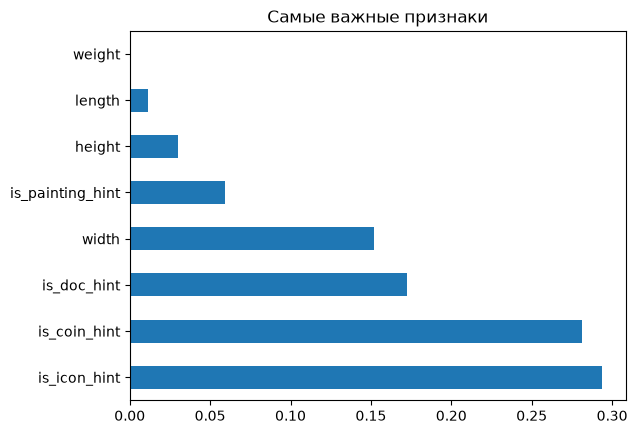

In [71]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Самые важные признаки")
plt.show()

#### Обучение ML модели RandomForestClassifier

In [72]:
# Подготовка данных
# Выделяем признаки (X) и целевую переменную (y)
X = df.drop(['target_label'], axis=1)
y = df['target_label']

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Построение и обучение модели
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Оценка результатов
predictions = model.predict(X_test)

print("\n--- Отчет о качестве (Random Forest) ---")
print(classification_report(y_test, predictions))

# Маппинг для красивого вывода (чтобы видеть названия, а не цифры 0, 1, 2, 3)
target_names = {0: 'ART', 1: 'DOCUMENTS', 2: 'ICON', 3: 'NUMISMATICS'}

# Демонстрация предсказания
cnt = 10
print(f"\n--- Примеры прогнозов (первые {cnt} тестов) ---")
for i in range(cnt):
    real_name = target_names.get(y_test.values[i])
    pred_name = target_names.get(predictions[i])
    
    print(f"Реально: {real_name:12} | Предсказано: {pred_name:12}")


--- Отчет о качестве (Random Forest) ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       657
           1       0.74      0.93      0.82       111
           2       0.94      0.96      0.95       549
           3       0.95      0.98      0.97       193

    accuracy                           0.93      1510
   macro avg       0.90      0.94      0.92      1510
weighted avg       0.94      0.93      0.93      1510


--- Примеры прогнозов (первые 10 тестов) ---
Реально: ICON         | Предсказано: ICON        
Реально: ART          | Предсказано: ART         
Реально: DOCUMENTS    | Предсказано: DOCUMENTS   
Реально: ICON         | Предсказано: ICON        
Реально: NUMISMATICS  | Предсказано: NUMISMATICS 
Реально: ART          | Предсказано: DOCUMENTS   
Реально: NUMISMATICS  | Предсказано: NUMISMATICS 
Реально: ART          | Предсказано: ART         
Реально: ART          | Предсказано: ART         
Реально: ICON         | Пре

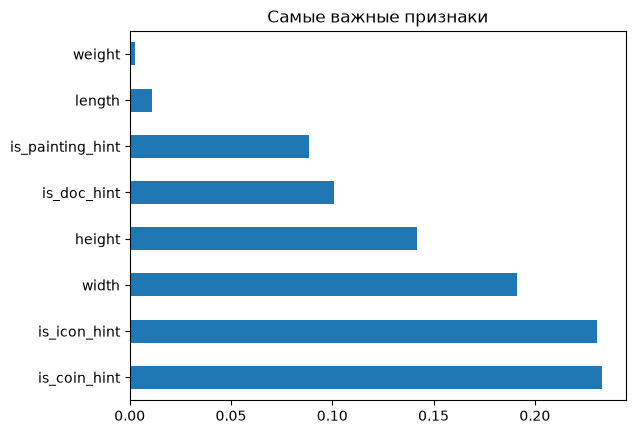

In [73]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Самые важные признаки")
plt.show()